In [2]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math

path_google = 'G:/Shared drives/'

def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galO_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label


def make_binary_model_OB(p): # OB pair
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

In [3]:
import sys
print(sys.executable)

c:\Users\alex\Documents\GitHub\BStarMiMeS\.venv\Scripts\python.exe


Found 3 observations for hd219634:
hd219634_1977051pnm_rn.s
hd219634_E_1737886pnm_rn.s
hd219634_E_1977051pnm_rn.s


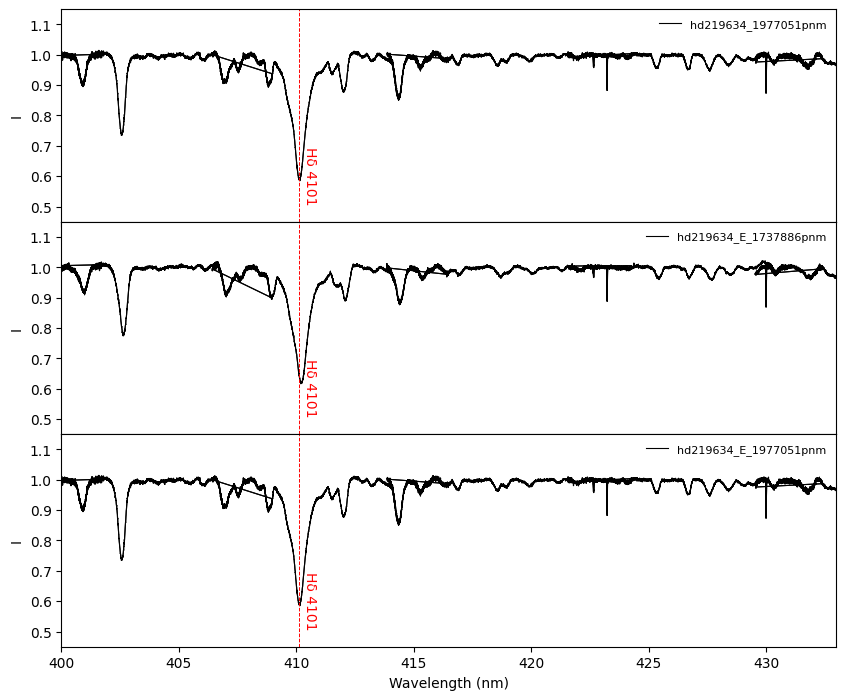

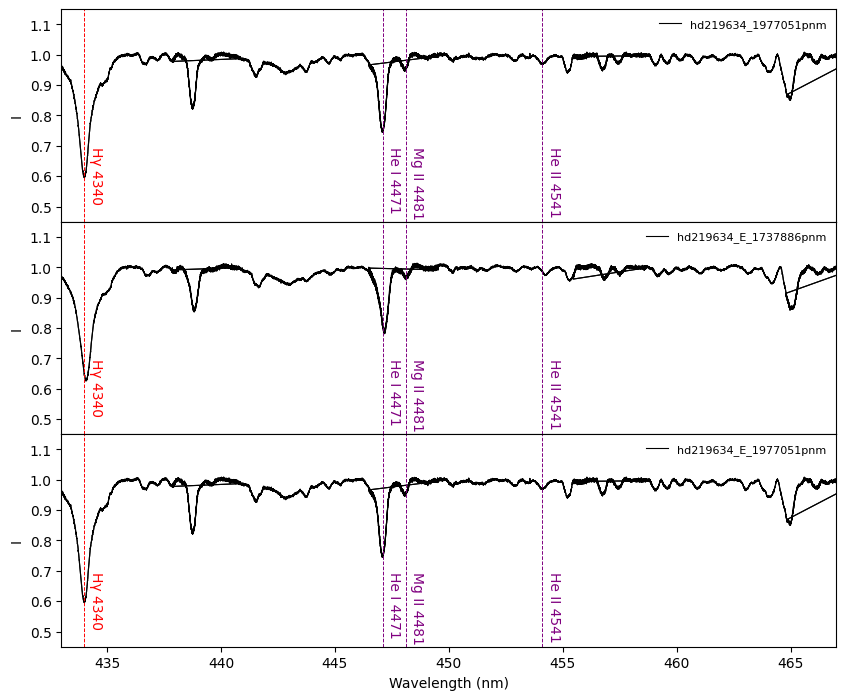

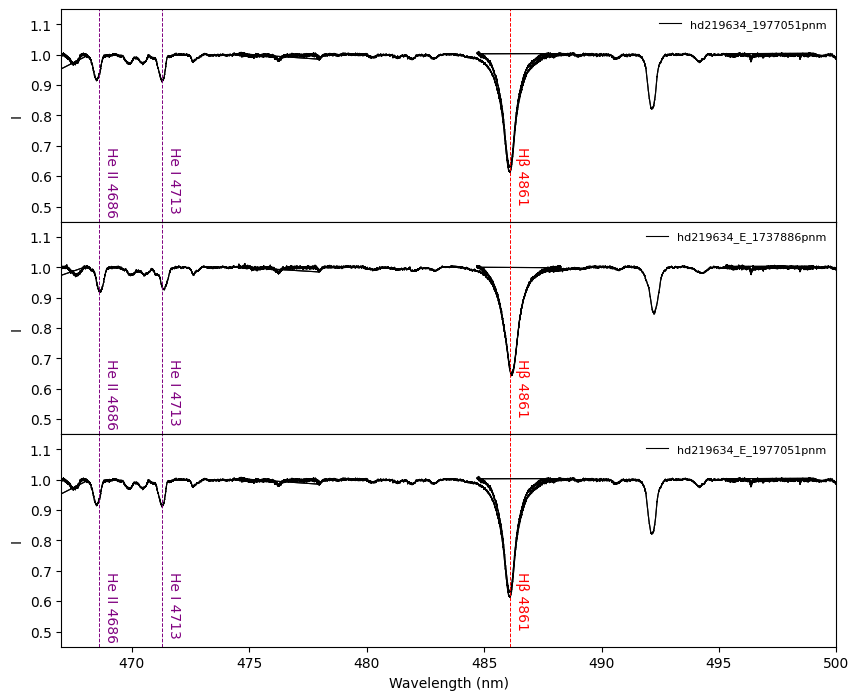

In [49]:
# "G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero/hd23625_2004924pnm_rn.s"

obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")

hd = "hd219634"      # Change this to whichever star you want

obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)


windows = [
    (400, 433),
    (433, 467),
    (467, 500),
]

lines_H = [
    (410.1, 'Hδ 4101'),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]
# Read all spectra first
spectra = []
for filename in obs:
    spectra.append((filename, pol.read_spectrum(obs_folder / filename)))

for xmin, xmax in windows:

    fig, ax = plt.subplots(
        len(spectra), 1,
        figsize=(10, 2.5 * len(spectra)),
        sharex=True
    )

    # If only one observation
    if len(spectra) == 1:
        ax = [ax]

    for i, (filename, spec) in enumerate(spectra):

        ax[i].plot(spec.wl, spec.specI, lw=0.8, color="black")

        ax[i].set_xlim(xmin, xmax)
        ax[i].set_ylim(0.45, 1.15)

        ax[i].set_ylabel("I")
        label = filename.replace("_rn.s", "")
        ax[i].plot(spec.wl, spec.specI, lw=0.8, color="black", label=label)
        ax[i].legend(loc="upper right", fontsize=8, frameon=False)
        # Hydrogen lines
        for wl, label in lines_H:
            if xmin <= wl <= xmax:
                ax[i].axvline(wl,color='red', ls='--',lw=0.7)

                ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,
                        ha='center',va='top')
        # Helium / metal lines
        for wl, label in lines_He:
            if xmin <= wl <= xmax:
                ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
                ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,
                        ha='center',va='top')



    ax[-1].set_xlabel("Wavelength (nm)")
    fig.subplots_adjust(hspace=0, top=0.93, bottom=0.08)
    plt.show()


In [72]:
print(obs)
name = obs[1]
spec = pol.read_spectrum(obs_folder / f"{name}")

['hd219634_1977051pnm_rn.s', 'hd219634_E_1737886pnm_rn.s', 'hd219634_E_1977051pnm_rn.s']


In [83]:
# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.

params_A = {
    "teff1": 32500, "logg1":400,
    "teff2": 32500, "logg2":375,
    "vsini1": 100, "vsini2": 100,
    "vrad1": 20, "vrad2":40,
    "R2R1":1,
    "vturb": 10,

}

params_B = {
    "teff1": 32500, "logg1":425,
    "teff2": 32500, "logg2":425,
    "vsini1": 100, "vsini2": 100,
    "vrad1": 20, "vrad2":40,
    "R2R1":1,
    "vturb": 10,

}

# model_A, label_A = make_binary_model_O(params_A)
# model_B, label_B = make_binary_model_O(params_B)
model_A, label_A = make_binary_model_O(params_A)
model_B, label_B = make_binary_model_O(params_B)


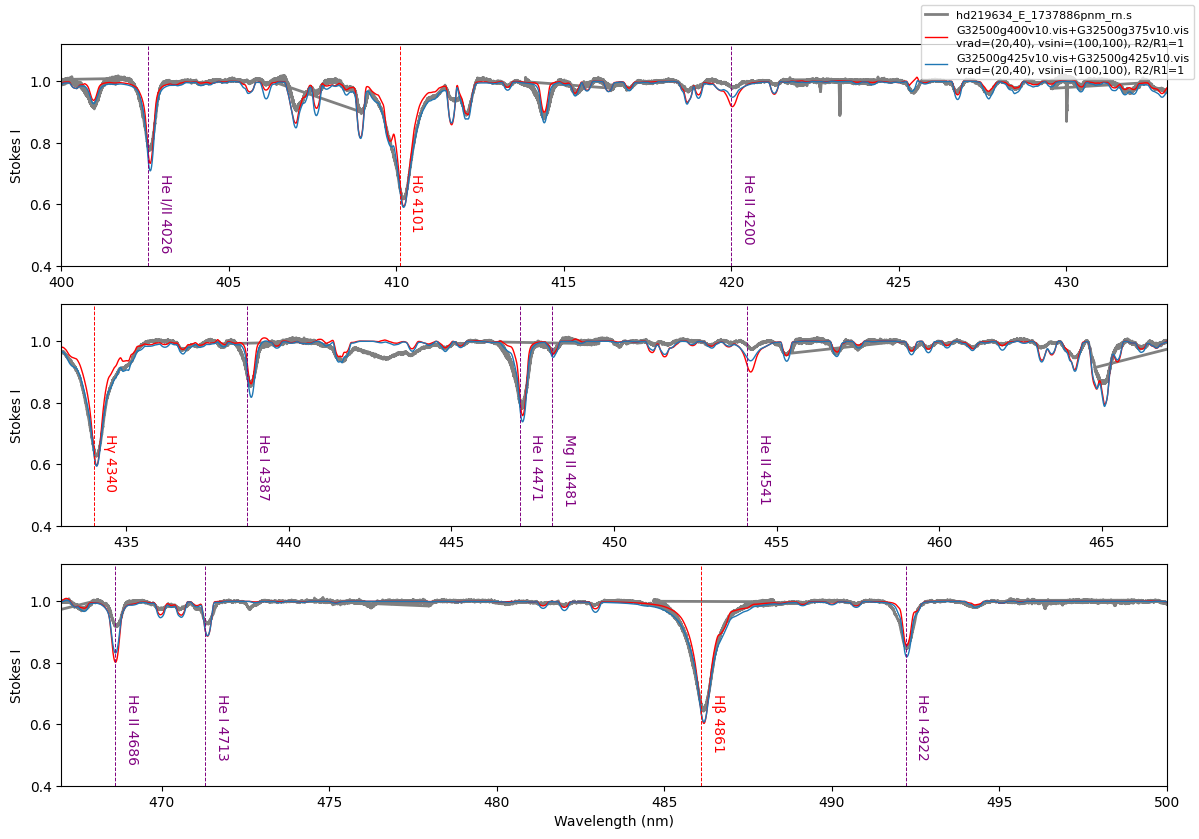

In [84]:
windows = [(400, 433),(433, 467),(467, 500)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [(402.6, "He I/II 4026"),(420.0, "He II 4200"),(438.7, "He I 4387"),(447.1, "He I 4471"),
            (448.1, "Mg II 4481"),(454.1, "He II 4541"),(468.6, "He II 4686"),(471.3, "He I 4713"),(492.2, "He I 4922"),
            (501.6, "He I 5016"),(580.1,"CIV 5801"),(581.1,"CIV 5811")]

fig, ax = plt.subplots(len(windows), 1,figsize=(12, 2.8 * len(windows)))

for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=2, color='grey', label=name)
    ax[i].plot(model_A.wl/10, model_A.specI, lw=1,color='red', label=label_A)
    ax[i].plot(model_B.wl/10, model_B.specI, lw=1, label=label_B)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red', ls='--',lw=0.7)

            ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,ha='center',va='top')
    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
            ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,ha='center',va='top')

ax[-1].set_xlabel("Wavelength (nm)")

# Only show legend once
handles, labels = ax[0].get_legend_handles_labels()


fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=8
)

# fig.suptitle("Comparison of TLUSTY Models",fontsize=15,y=0.99)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

In [85]:
params_B = {
    "teff1": 32500, "logg1":425,
    "teff2": 32500, "logg2":425,
    "vsini1": 100, "vsini2": 100,
    "vrad1": 20, "vrad2":40,
    "R2R1":1,
    "vturb": 10,

}

model_B, label_B = make_binary_model_O(params_B)


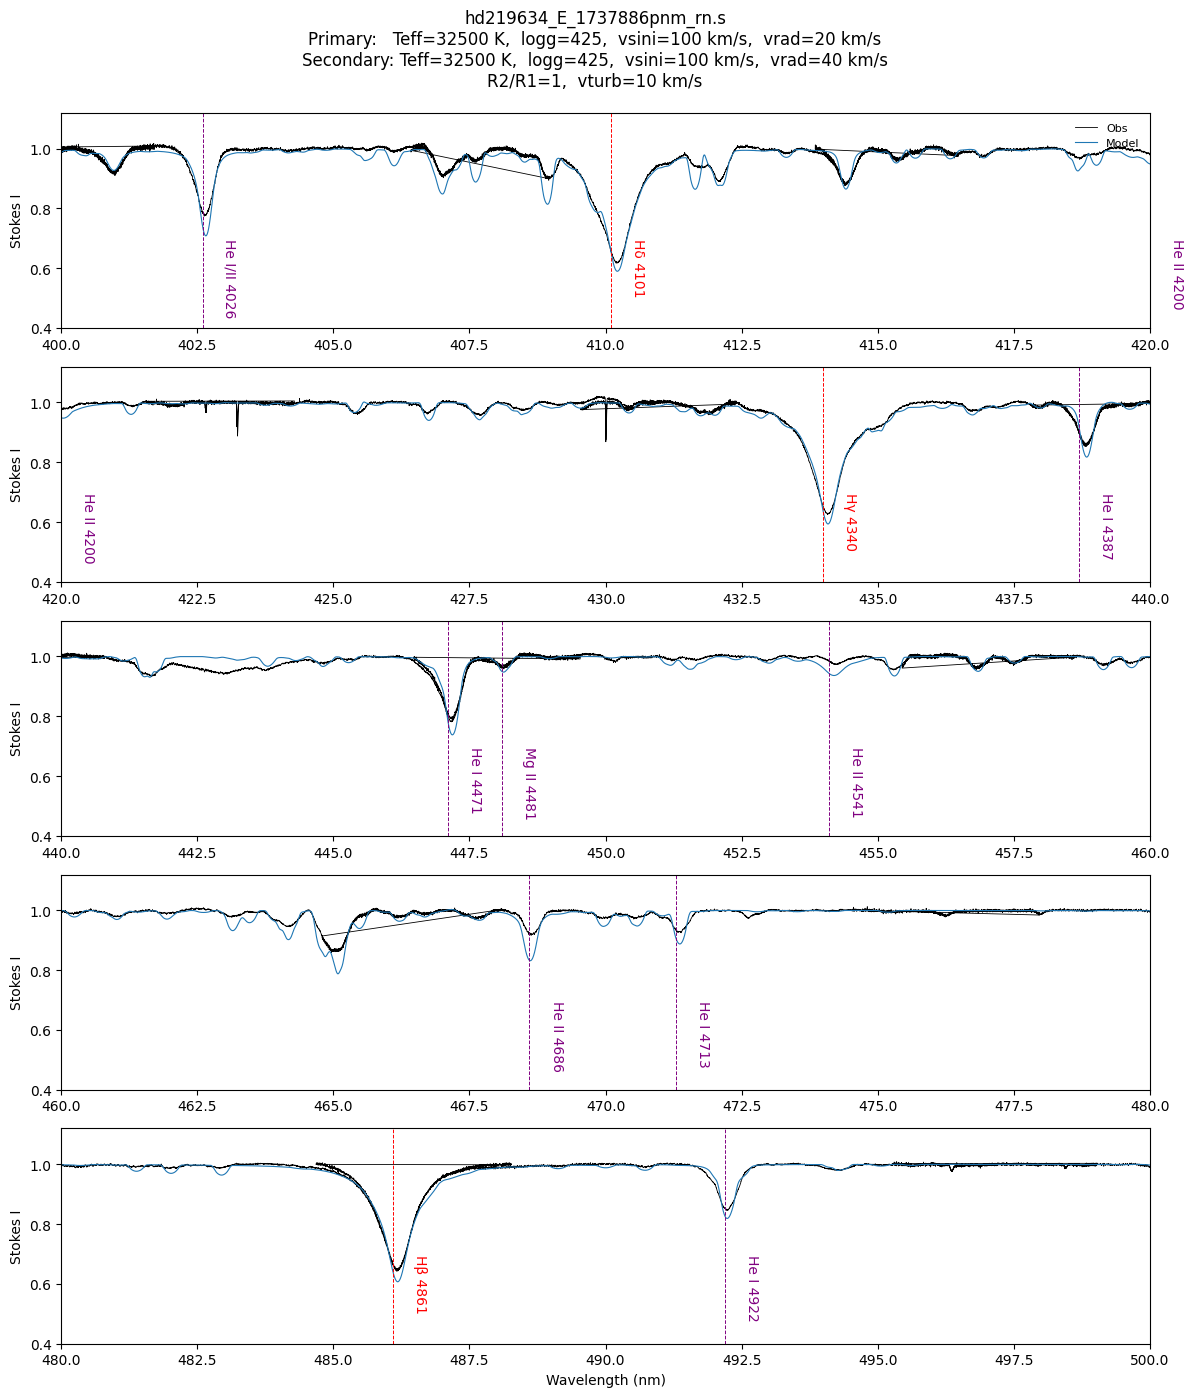

In [86]:
windows = [(400, 420),(420, 440),(440, 460),(460, 480),(480, 500)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [(402.6, "He I/II 4026"),(420.0, "He II 4200"),(438.7, "He I 4387"),(447.1, "He I 4471"),
            (448.1, "Mg II 4481"),(454.1, "He II 4541"),(468.6, "He II 4686"),(471.3, "He I 4713"),(492.2, "He I 4922"),
            (501.6, "He I 5016"),(580.1,"CIV 5801"),(581.1,"CIV 5811")]



# model_A, label_A = make_binary_model(params_A)

fig, ax = plt.subplots(len(windows), 1,figsize=(12, 2.8 * len(windows)))
param_text = (
    f"Primary:   Teff={params_B['teff1']} K,  logg={params_B['logg1']},  "
    f"vsini={params_B['vsini1']} km/s,  vrad={params_B['vrad1']} km/s\n"
    f"Secondary: Teff={params_B['teff2']} K,  logg={params_B['logg2']},  "
    f"vsini={params_B['vsini2']} km/s,  vrad={params_B['vrad2']} km/s\n"
    f"R2/R1={params_B['R2R1']},  vturb={params_B['vturb']} km/s"
)


for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, color='k', label='Obs')
    ax[i].plot(model_B.wl/10, model_B.specI, lw=0.8, label='Model')
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red', ls='--',lw=0.7)

            ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,ha='center',va='top')
    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
            ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,ha='center',va='top')

ax[-1].set_xlabel("Wavelength (nm)")

# Only show legend once
handles, labels = ax[0].get_legend_handles_labels()


ax[0].legend(loc="upper right", fontsize=8, frameon=False)

fig.suptitle(
    f"{name}\n{param_text}",
    fontsize=12,
    y=0.995
)
fig.tight_layout()

plt.show()

In [ ]:
def dopplershift_rotate(spectrum, dopplershift, vsini):
    """Apply radial-velocity shift followed by rotational broadening."""
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    broadened_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return broadened_spectrum


def make_single_model(params):

    grid = params["grid"].upper()

    if grid == "B":
        path_template = vp.tlusty.galB_path_name
    elif grid == "O":
        path_template = vp.tlusty.galO_path_name
    else:
        raise ValueError(
            f"Unknown grid {params['grid']!r}. "
            "Expected 'B' or 'O'."
        )

    model_path = path_template.format(
        "vis",
        params["teff"],
        params["logg"],
        str(params["vturb"]),
    )

    full_model_path = path_google + model_path

    model = vp.tlusty.read_norm(full_model_path)

    model = dopplershift_rotate(
        spectrum=model,
        dopplershift=params["vrad"],
        vsini=params["vsini"],
    )

    return model
def make_binary_components(params):
    """
    Generate the two binary components separately.
    """

    params_1 = {
        "grid": params["grid_1"],
        "teff": params["teff1"],
        "logg": params["logg1"],
        "vsini": params["vsini1"],
        "vrad": params["vrad1"],
        "vturb": params.get("vturb1", params["vturb"]),
    }

    params_2 = {
        "grid": params["grid_2"],
        "teff": params["teff2"],
        "logg": params["logg2"],
        "vsini": params["vsini2"],
        "vrad": params["vrad2"],
        "vturb": params.get("vturb2", params["vturb"]),
    }

    component_1 = make_single_model(params_1)
    component_2 = make_single_model(params_2)

    label_1 = (
        rf"Component 1 ({params_1['grid']}-grid): "
        rf"$T_{{\rm eff}}={params_1['teff']}$ K, "
        rf"$\log g={params_1['logg'] / 100:.2f}$, "
        rf"$v\sin i={params_1['vsini']}$ km s$^{{-1}}$, "
        rf"$v_r={params_1['vrad']}$ km s$^{{-1}}$"
    )

    label_2 = (
        rf"Component 2 ({params_2['grid']}-grid): "
        rf"$T_{{\rm eff}}={params_2['teff']}$ K, "
        rf"$\log g={params_2['logg'] / 100:.2f}$, "
        rf"$v\sin i={params_2['vsini']}$ km s$^{{-1}}$, "
        rf"$v_r={params_2['vrad']}$ km s$^{{-1}}$"
    )

    return component_1, component_2, label_1, label_2


In [30]:
print(obs)
name = obs[1]
spec = pol.read_spectrum(obs_folder / f"{name}")
params_B = {
    "grid_1":"B", "grid_2":"B",
    "teff1": 18000, "logg1":400,
    "teff2": 17000, "logg2":350,
    "vsini1": 50, "vsini2": 50,
    "vrad1": -30, "vrad2": 30,
    "R2R1":1.3,
    "vturb": 2,
}


['hd23625_2004924pnm_rn.s', 'hd23625_E_1650068pnm_rn.s', 'hd23625_E_2004924pnm_rn.s']


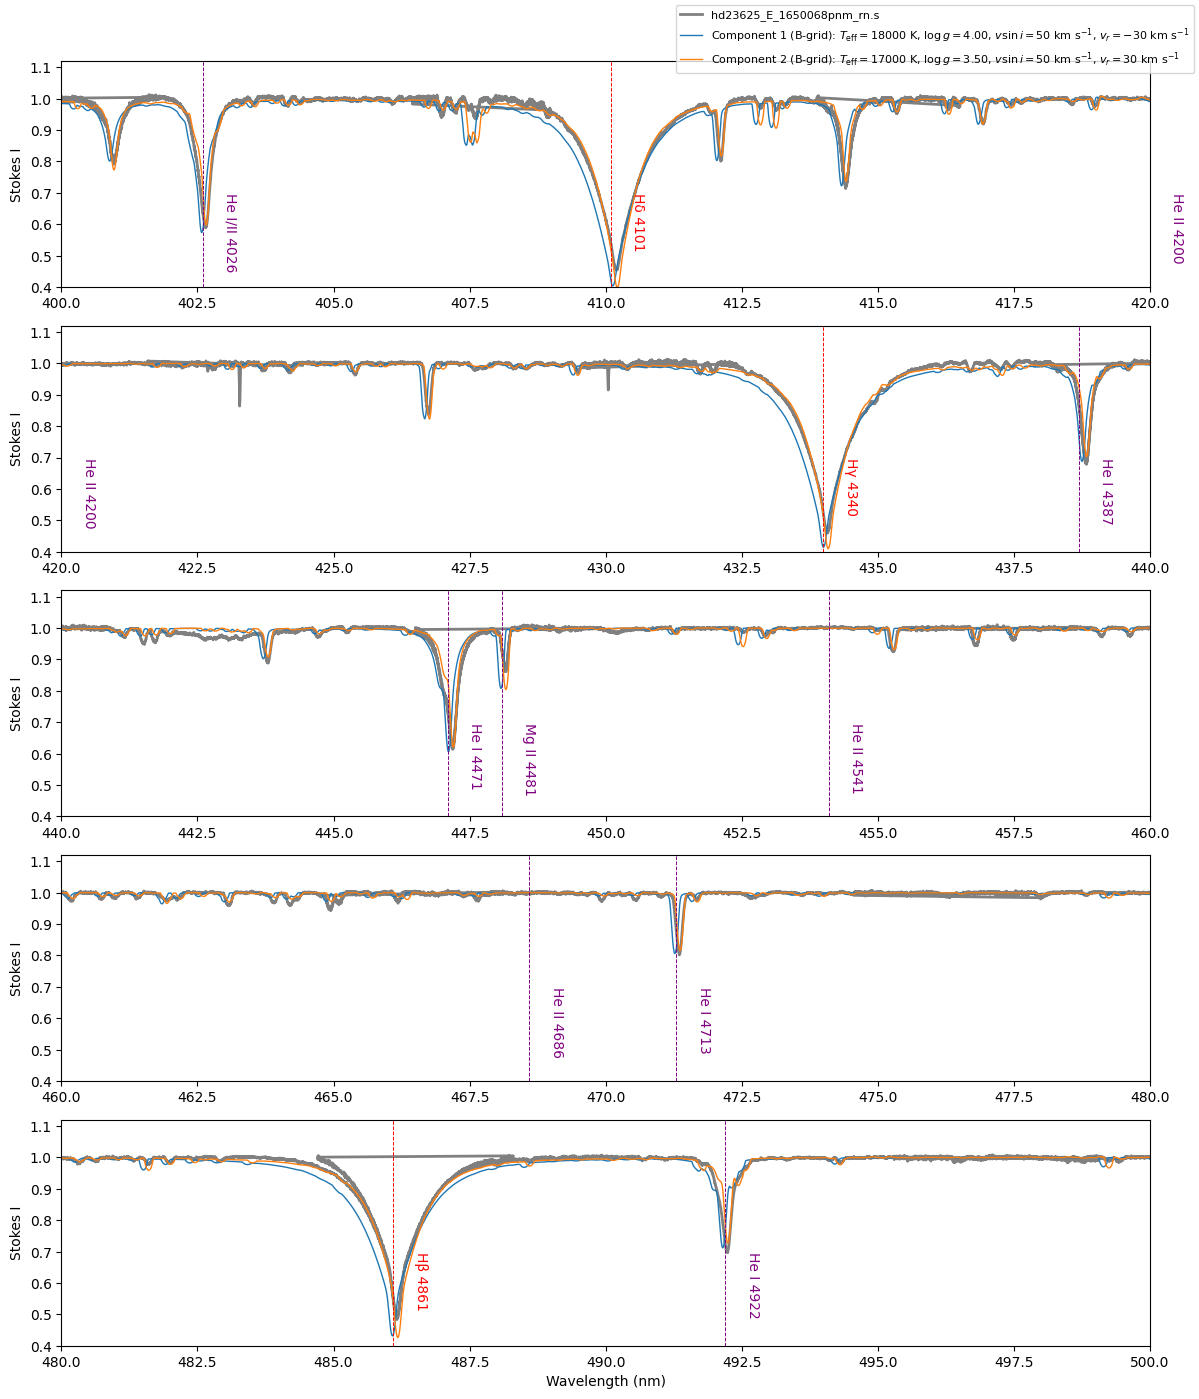

In [31]:
component_1, component_2, label_1, label_2 = (
    make_binary_components(params_B)
)
windows = [
    (400, 420),
    (420, 440),
    (440, 460),
    (460, 480),
    (480, 500)
]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),
]

# (
#     common_wl,
#     diluted_1,
#     diluted_2,
#     combined,
#     light_1,
#     light_2,
# ) = radius_weight_components(
#     component_1,
#     component_2,
#     params_B["R2R1"],
# )

fig, ax = plt.subplots(
    len(windows),
    1,
    figsize=(12, 2.8 * len(windows)),
)

for i, (xmin, xmax) in enumerate(windows):
    # Observed spectrum
    ax[i].plot(
        spec.wl,
        spec.specI,
        lw=2,
        color="grey",
        label=name,
    )

    # Separate stellar components
    ax[i].plot(
        component_1.wl / 10,
        component_1.specI,
        lw=1,
        label=label_1,
    )

    ax[i].plot(
        component_2.wl / 10,
        component_2.specI,
        lw=1,
        label=label_2,
    )
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    for wl, line_label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(
                wl,
                color="red",
                ls="--",
                lw=0.7,
            )
            ax[i].text(
                wl + 0.5,
                0.70,
                line_label,
                color="red",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top",
            )

    for wl, line_label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(
                wl,
                color="purple",
                ls="--",
                lw=0.7,
            )
            ax[i].text(
                wl + 0.5,
                0.70,
                line_label,
                color="purple",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top",
            )

ax[-1].set_xlabel("Wavelength (nm)")

handles, legend_labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper right",
    fontsize=8,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()